# Análisis Exploratorio de Datos (EDA)

In [ ]:
%pip install numpy
%pip install pandas
%pip install seaborn
%pip install matplotlib.pylot

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pylot (from versions: none)
ERROR: No matching distribution found for matplotlib.pylot


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

# Cargar el Dataset
df = pd.read_csv('data/retailmax.csv')

# 1. ¿Cuál es la distribución de edades de los clientes?

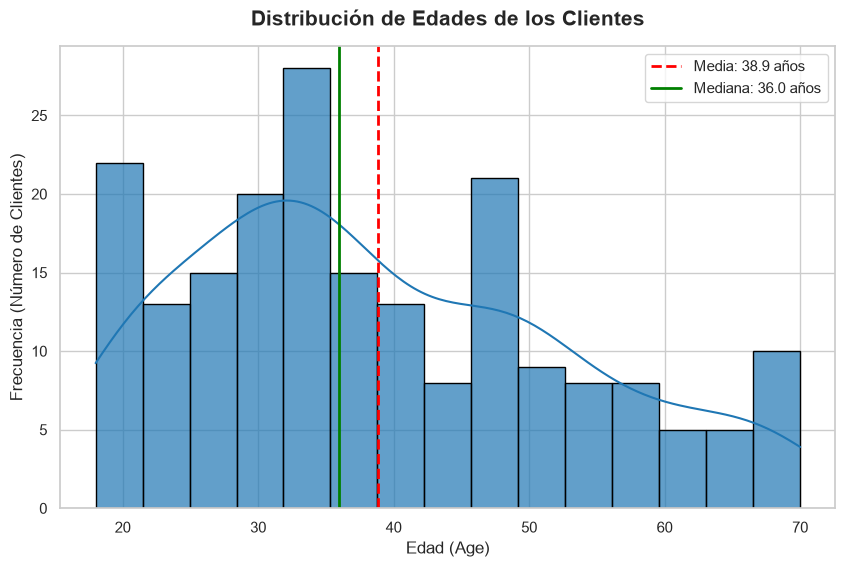

In [ ]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=15, kde=True, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.title('Distribución de Edades de los Clientes', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Age"].mean():.1f} años')
plt.axvline(df['Age'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df["Age"].median():.1f} años')
plt.legend(fontsize=11)
plt.show()

# 2. ¿Existen diferencias en los ingresos anuales entre hombres y mujeres?

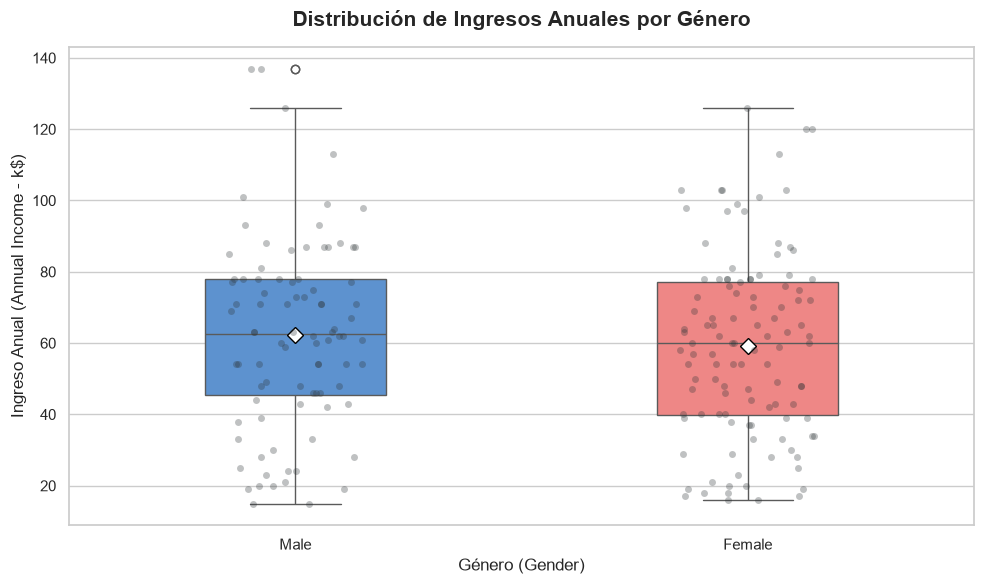

In [ ]:
plt.figure(figsize=(10, 6))

# Gráfico de caja (boxplot) con strip plot superpuesto para ver la distribución individual
sns.boxplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    width=0.4,
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Mostrar los puntos individuales de datos de manera sutil
sns.stripplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    color='#2d3436', 
    alpha=0.3, 
    jitter=0.15, 
    size=5
)

plt.title('Distribución de Ingresos Anuales por Género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género (Gender)', fontsize=12)
plt.ylabel('Ingreso Anual (Annual Income - k$)', fontsize=12)

plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de ingresos anuales entre hombres y mujeres, observamos que **no existen diferencias drásticas**, aunque sí se aprecian ligeras variaciones a favor del grupo masculino:

1. **Promedio (Media) y Mediana:**
   - Los **hombres** tienen un ingreso anual promedio de **62.23 k$** y una mediana de **62.50 k$**.
   - Las **mujeres** tienen un ingreso anual promedio de **59.25 k$** y una mediana de **60.00 k$**.
   - Esto representa una ligera diferencia de **~2.98 k$ en la media** y **2.50 k$ en la mediana** a favor de los hombres.

2. **Dispersión y Límites:**
   - La dispersión (desviación estándar) es sumamente similar en ambos grupos: **26.64 k$** para hombres y **26.01 k$** para mujeres.
   - Los rangos intercuartílicos y las cajas en el gráfico muestran que el 50% central de la población se encuentra en rangos muy similares, aunque el límite inferior del 25% de los hombres (45.5 k$) es ligeramente mayor al de las mujeres (39.75 k$).
   - El ingreso máximo registrado pertenece a un hombre con **137 k$**, mientras que el de las mujeres es de **126 k$**.

**Conclusión:** Aunque estadísticamente los hombres muestran ingresos ligeramente superiores en términos de medidas de tendencia central (media y mediana) y valores máximos, las distribuciones se superponen en gran medida. Esto sugiere que **el género no es un factor determinante o altamente diferenciador** para el nivel de ingresos en este conjunto de datos.

# 3. ¿Cómo se distribuye la puntuación de gastos entre los diferentes rangos de edades?

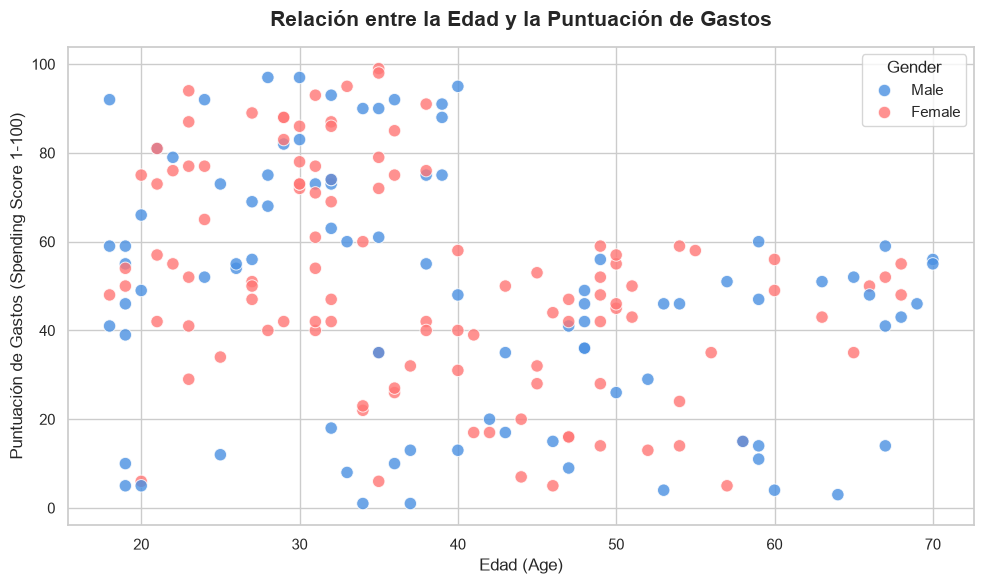

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)',
    hue='Gender',
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    alpha=0.8,
    s=80
)

plt.title('Relación entre la Edad y la Puntuación de Gastos', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Puntuación de Gastos (Spending Score 1-100)', fontsize=12)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de la puntuación de gastos (`Spending Score (1-100)`) en función de la edad (`Age`), podemos extraer conclusiones muy claras y valiosas sobre el comportamiento de los clientes:

1. **Límite de Edad para Altos Consumidores:**
   - Se observa una clara barrera alrededor de los **40 años**. Prácticamente **ningún cliente mayor de 40 años supera una puntuación de gasto de 60**.
   - La gran mayoría de los clientes de más de 40 años se concentra en un rango de puntuación moderado y bajo (entre 1 y 60 puntos), con una media que ronda los **32-34 puntos**.

2. **Comportamiento en Clientes Jóvenes (< 40 años):**
   - Los clientes de entre 18 y 40 años muestran una dispersión mucho mayor y son los únicos que alcanzan puntuaciones de gastos sobresalientes (entre 60 y 100 puntos).
   - En este segmento joven, se aprecian claramente dos grupos bien diferenciados: uno de perfil muy ahorrador/moderado (puntuaciones bajas) y otro de perfil altamente consumidor (puntuaciones que van de 60 a 99 puntos).

**Conclusión:** La edad es un factor altamente segmentador en este conjunto de datos. Mientras que los clientes jóvenes (< 40 años) presentan un grupo con potencial de compra sumamente elevado, el segmento de mayor edad (>= 40 años) exhibe un comportamiento de gasto mucho más moderado y homogéneo, sin superar nunca la franja alta de puntuación.

# 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?

Coeficiente de correlación de Pearson: 0.010


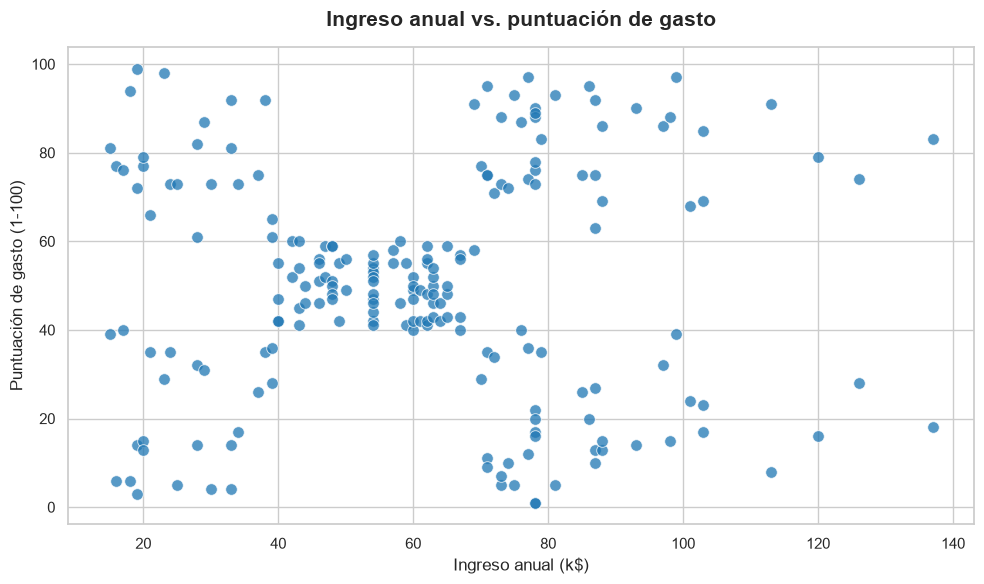

In [ ]:
correlacion = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
print(f'Coeficiente de correlación de Pearson: {correlacion:.3f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    color='#1f77b4',
    alpha=0.75,
    s=70
)
plt.title('Ingreso anual vs. puntuación de gasto', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Ingreso anual (k$)', fontsize=12)
plt.ylabel('Puntuación de gasto (1-100)', fontsize=12)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

- **Coeficiente de correlación:** El valor de Pearson es aproximadamente **0.010**, lo que indica una relación lineal prácticamente **nula** entre `Annual Income (k$)` y `Spending Score (1-100)`.
- **Interpretación:** Una correlación cercana a cero significa que, en este dataset, los cambios en el ingreso anual no están asociados de manera lineal con aumentos o disminuciones consistentes en la puntuación de gasto.
- **Gráfica de dispersión:** Los puntos aparecen ampliamente dispersos, sin formar una tendencia ascendente o descendente clara; esta dispersión es una observación visual y coincide con el bajo valor de la correlación.
- **Conclusión:** No se observa una relación lineal entre ambas variables. Este resultado describe una asociación estadística y no implica causalidad.

# 5. ¿Cómo varía la puntuación de gasto por grupos de ingreso anual?

**Plan:** Crear rangos de ingreso, resumir la puntuación de gasto por grupo y comparar sus distribuciones mediante un boxplot.

,Clientes,Promedio,Mediana
Income Range (k$),,,
0-30,32,49.66,50.5
31-60,66,50.20,50.5
61-90,80,49.92,48.5
91-120,18,52.28,53.5
121+,4,50.75,51.0


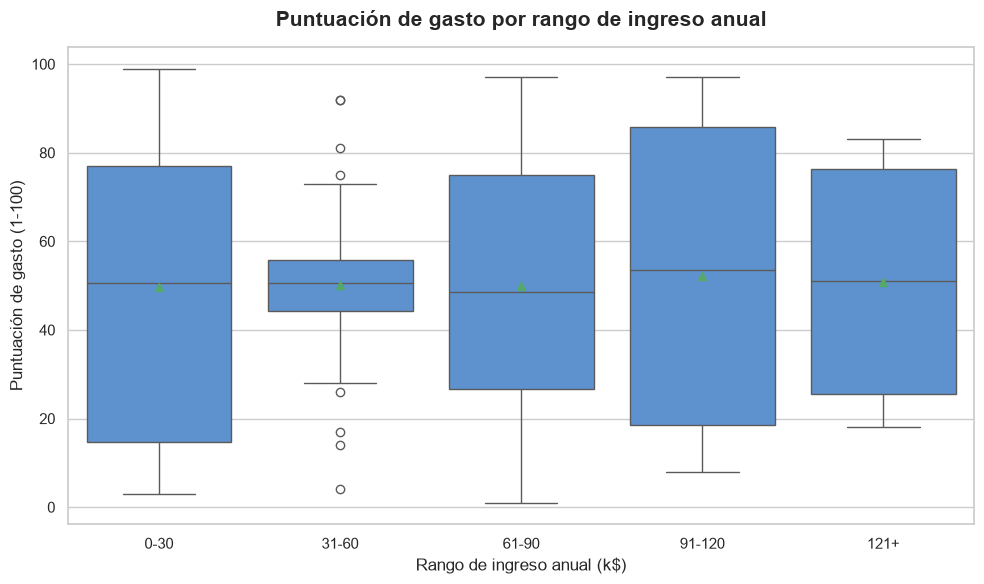

In [ ]:
income_bins = [0, 30, 60, 90, 120, np.inf]
income_labels = ['0-30', '31-60', '61-90', '91-120', '121+']

df['Income Range (k$)'] = pd.cut(
    df['Annual Income (k$)'],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

income_summary = (
    df.groupby('Income Range (k$)', observed=True)['Spending Score (1-100)']
      .agg(Clientes='count', Promedio='mean', Mediana='median')
      .round(2)
)
display(income_summary)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Income Range (k$)',
    y='Spending Score (1-100)',
    color='#4a90e2',
    showmeans=True
)
plt.title('Puntuación de gasto por rango de ingreso anual', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Rango de ingreso anual (k$)', fontsize=12)
plt.ylabel('Puntuación de gasto (1-100)', fontsize=12)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

- **Nivel promedio:** Los promedios de gasto son similares entre los rangos y se encuentran entre **49.66** y **52.28** puntos; el grupo de **91-120 k$** presenta el promedio más alto, pero la diferencia frente a los demás es pequeña.
- **Tendencia entre grupos:** Las medianas varían de **48.5** a **53.5** y no aumentan de forma continua con el ingreso, por lo que estos rangos no muestran una tendencia ordenada de mayor ingreso asociado con mayor puntuación de gasto.
- **Dispersión visual:** El boxplot muestra una variación amplia de puntuaciones dentro de varios grupos y un solapamiento considerable entre sus distribuciones; esto se describe como una observación visual, no como evidencia de causalidad.
- **Tamaño de los grupos:** El rango de **121+ k$** contiene solo **4 clientes**, por lo que su promedio de **50.75** debe interpretarse con cautela y no permite una comparación tan estable como la de los grupos más numerosos.

# 6. ¿Cuál es la proporción de clientes por género?

**Plan:** Calcular el número y porcentaje de clientes por género y representar la comparación mediante una gráfica de barras.

,Gender,Clientes,Porcentaje
0,Female,112,56.0
1,Male,88,44.0


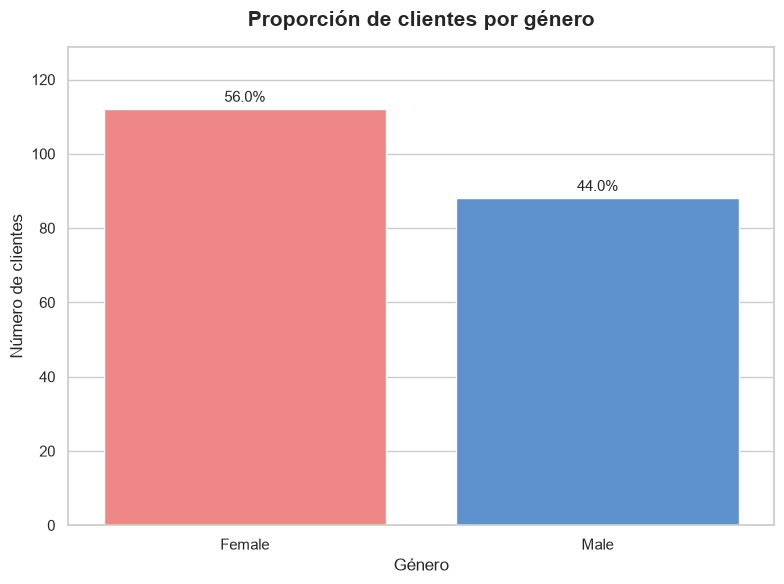

In [ ]:
gender_summary = (
    df['Gender']
      .value_counts()
      .rename_axis('Gender')
      .reset_index(name='Clientes')
)
gender_summary['Porcentaje'] = (
    gender_summary['Clientes'] / len(df) * 100
).round(1)
display(gender_summary)

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=gender_summary,
    x='Gender',
    y='Clientes',
    hue='Gender',
    palette={'Female': '#ff7675', 'Male': '#4a90e2'},
    legend=False
)

for index, row in gender_summary.iterrows():
    ax.text(index, row['Clientes'] + 2, f"{row['Porcentaje']:.1f}%", ha='center', fontsize=11)

plt.title('Proporción de clientes por género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Número de clientes', fontsize=12)
plt.ylim(0, gender_summary['Clientes'].max() * 1.15)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

- **Distribución:** De los **200 clientes**, **112 son mujeres (56.0%)** y **88 son hombres (44.0%)**.
- **Diferencia observada:** La muestra contiene **24 mujeres más** que hombres, equivalente a una diferencia de **12 puntos porcentuales** entre ambos grupos.
- **Lectura de la gráfica:** La barra correspondiente a las mujeres es moderadamente más alta, aunque ambos géneros mantienen una presencia relevante en el dataset.
- **Conclusión:** La distribución no es completamente equilibrada y presenta una mayor representación femenina; este resultado describe solamente la composición de la muestra analizada.

# 7. ¿Qué grupos de edad gastan más en promedio?

**Plan:** Crear rangos de edad, calcular el promedio de la puntuación de gasto por grupo y compararlos mediante una gráfica de barras.

,Age Range,Clientes,Promedio
0,18-25,38,54.95
1,26-35,60,64.45
2,36-45,36,44.83
3,46-55,37,36.70
4,56-65,17,32.12
5,66+,12,47.25


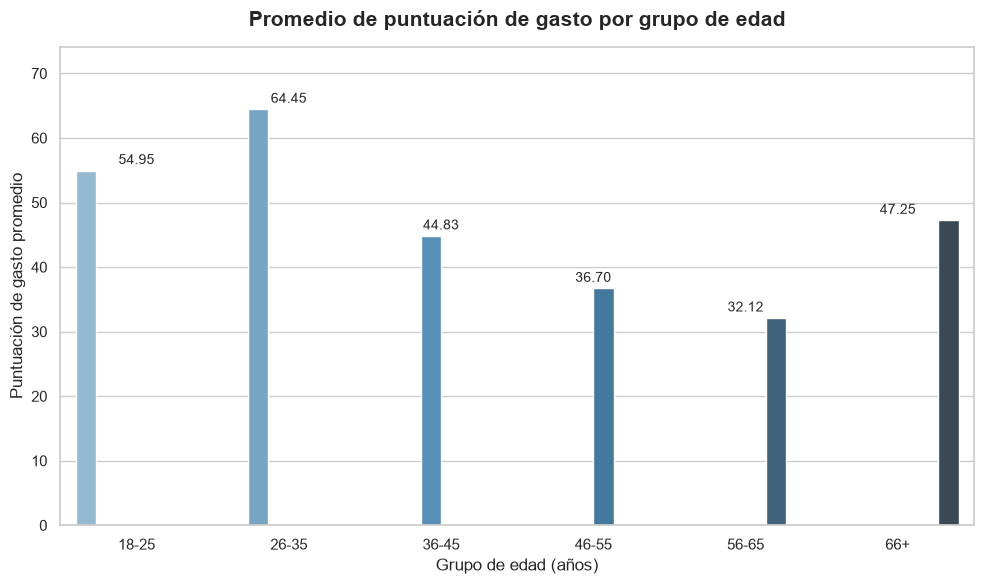

In [ ]:
age_bins = [17, 25, 35, 45, 55, 65, np.inf]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']

df['Age Range'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels
)

age_summary = (
    df.groupby('Age Range', observed=True)['Spending Score (1-100)']
      .agg(Clientes='count', Promedio='mean')
      .round(2)
      .reset_index()
)
display(age_summary)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=age_summary,
    x='Age Range',
    y='Promedio',
    hue='Age Range',
    palette='Blues_d',
    legend=False
)

for index, row in age_summary.iterrows():
    ax.text(index, row['Promedio'] + 1, f"{row['Promedio']:.2f}", ha='center', fontsize=10)

plt.title('Promedio de puntuación de gasto por grupo de edad', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Grupo de edad (años)', fontsize=12)
plt.ylabel('Puntuación de gasto promedio', fontsize=12)
plt.ylim(0, age_summary['Promedio'].max() * 1.15)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

- **Mayor promedio:** El grupo de **26-35 años** registra la puntuación de gasto promedio más alta, con **64.45 puntos** entre **60 clientes**; le sigue el grupo de **18-25 años**, con **54.95 puntos** entre **38 clientes**.
- **Menor promedio:** El grupo de **56-65 años** presenta el promedio más bajo, con **32.12 puntos** entre **17 clientes**.
- **Comportamiento observado:** En la gráfica, el promedio disminuye desde el grupo de **26-35** hasta el de **56-65 años**, pero aumenta a **47.25 puntos** en el grupo de **66+**; por ello, no se observa una disminución continua en todos los rangos.
- **Conclusión:** Dentro de los rangos definidos, los clientes de **26-35 años** son quienes obtienen el mayor gasto promedio. Esta comparación describe el dataset y no implica que la edad cause el nivel de gasto.

# 8. ¿Qué relación existe entre la edad y el ingreso anual?

**Plan:** Calcular la correlación entre edad e ingreso anual y visualizar ambas variables mediante una gráfica de dispersión con línea de tendencia.

Coeficiente de correlación de Pearson: -0.012


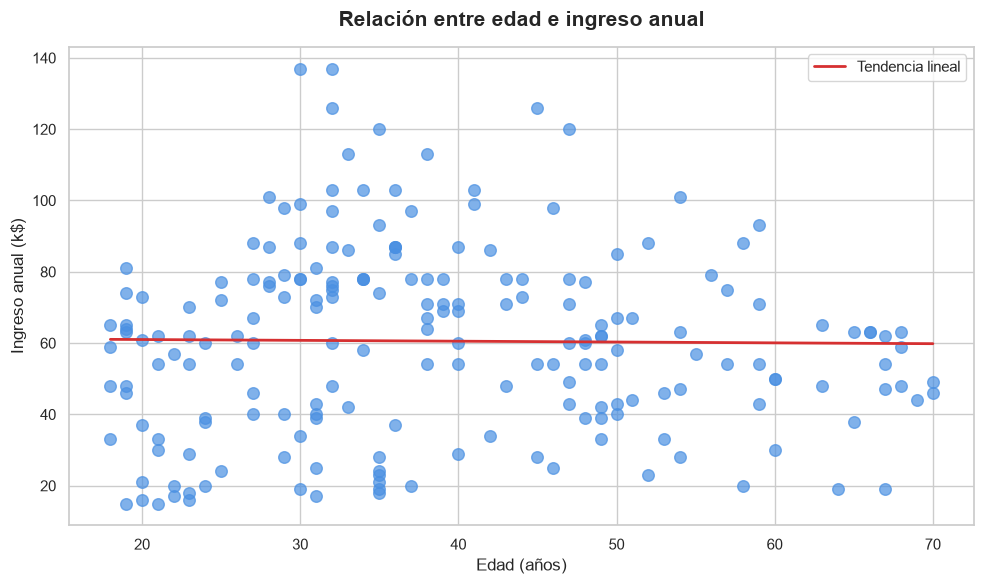

In [ ]:
age_income_correlation = df['Age'].corr(df['Annual Income (k$)'])
print(f'Coeficiente de correlación de Pearson: {age_income_correlation:.3f}')

plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='Age',
    y='Annual Income (k$)',
    ci=None,
    scatter_kws={'alpha': 0.7, 's': 70, 'color': '#4a90e2'},
    line_kws={'color': '#d63031', 'linewidth': 2, 'label': 'Tendencia lineal'}
)
plt.title('Relación entre edad e ingreso anual', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Ingreso anual (k$)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

- **Coeficiente de correlación:** El valor de Pearson es aproximadamente **-0.012**, lo que representa una relación lineal prácticamente **nula** entre `Age` y `Annual Income (k$)`.
- **Interpretación:** Un valor tan cercano a cero indica que, en este dataset, una mayor edad no está asociada de forma lineal y consistente con un aumento o una disminución del ingreso anual.
- **Gráfica de dispersión:** Los puntos se observan ampliamente dispersos y la línea de tendencia es casi horizontal, sin una dirección ascendente o descendente clara.
- **Conclusión:** No se observa una relación lineal apreciable entre la edad y el ingreso anual. El resultado describe una asociación en esta muestra y no implica causalidad.

# 9. ¿Cómo se distribuyen conjuntamente la edad y el ingreso anual?

**Plan:** Representar la distribución conjunta mediante un gráfico hexbin, donde el color indique la cantidad de clientes concentrados en cada zona.

Clientes entre 20-50 años e ingresos de 40-80 k$: 79 (39.5%)


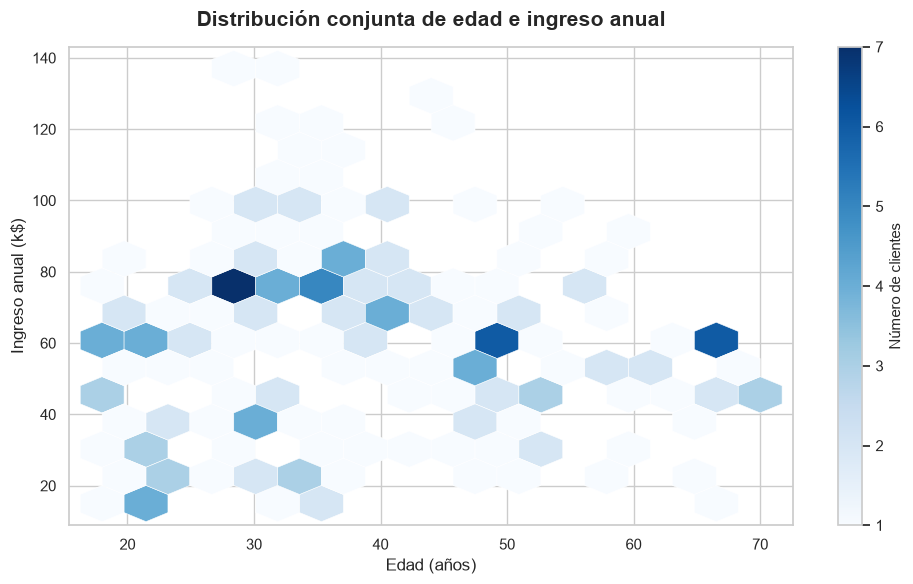

In [ ]:
joint_region_count = (
    df['Age'].between(20, 50)
    & df['Annual Income (k$)'].between(40, 80)
).sum()
joint_region_percentage = joint_region_count / len(df) * 100

print(
    f'Clientes entre 20-50 años e ingresos de 40-80 k$: '
    f'{joint_region_count} ({joint_region_percentage:.1f}%)'
)

fig, ax = plt.subplots(figsize=(10, 6))
hexbin = ax.hexbin(
    df['Age'],
    df['Annual Income (k$)'],
    gridsize=15,
    cmap='Blues',
    mincnt=1,
    edgecolors='white',
    linewidths=0.4
)
colorbar = fig.colorbar(hexbin, ax=ax)
colorbar.set_label('Número de clientes', fontsize=11)

ax.set_title('Distribución conjunta de edad e ingreso anual', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Edad (años)', fontsize=12)
ax.set_ylabel('Ingreso anual (k$)', fontsize=12)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

- **Cobertura de la distribución:** Los clientes abarcan edades de **18 a 70 años** e ingresos anuales de **15 a 137 k$**, por lo que la muestra se extiende sobre un rango amplio en ambas variables.
- **Concentración conjunta:** **79 clientes (39.5%)** se encuentran simultáneamente entre **20 y 50 años** y entre **40 y 80 k$** de ingreso anual.
- **Lectura del hexbin:** Las zonas más oscuras representan una mayor cantidad de clientes, mientras que las zonas claras corresponden a combinaciones menos frecuentes; visualmente, la distribución no se concentra en una sola combinación de edad e ingreso.
- **Conclusión:** La gráfica muestra una distribución conjunta amplia y con distintos niveles de densidad. Describe dónde se ubican los clientes de esta muestra, sin establecer causalidad entre la edad y el ingreso.

# 10. ¿Cómo se distribuye la puntuación de gasto según el género?

**Plan:** Resumir la puntuación de gasto por género y comparar visualmente sus distribuciones mediante un violinplot con las observaciones individuales.

,Clientes,Promedio,Mediana,Desviación
Gender,,,,
Female,112,51.53,50.0,24.11
Male,88,48.51,50.0,27.90


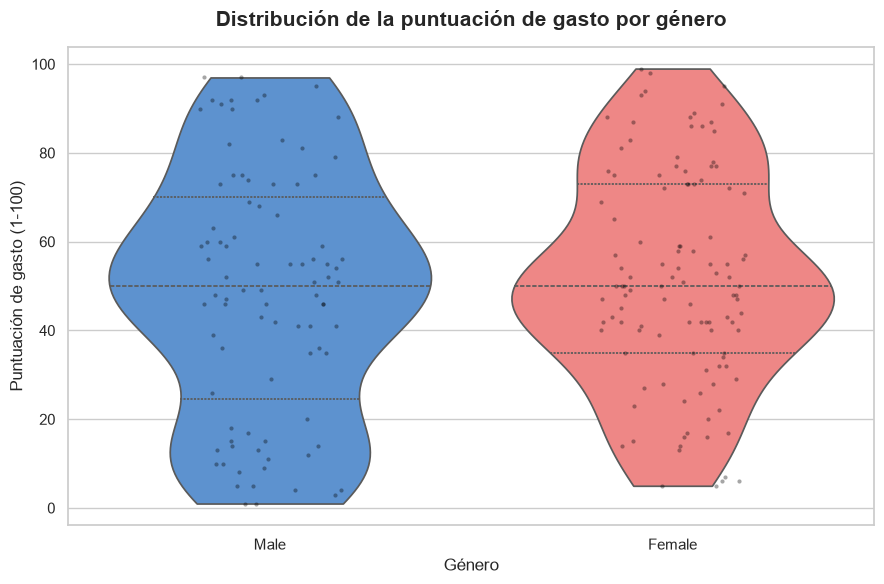

In [ ]:
gender_spending_summary = (
    df.groupby('Gender')['Spending Score (1-100)']
      .agg(Clientes='count', Promedio='mean', Mediana='median', Desviación='std')
      .round(2)
)
display(gender_spending_summary)

plt.figure(figsize=(9, 6))
sns.violinplot(
    data=df,
    x='Gender',
    y='Spending Score (1-100)',
    hue='Gender',
    palette={'Female': '#ff7675', 'Male': '#4a90e2'},
    inner='quartile',
    cut=0,
    legend=False
)
sns.stripplot(
    data=df,
    x='Gender',
    y='Spending Score (1-100)',
    color='black',
    alpha=0.35,
    size=3,
    jitter=0.18
)
plt.title('Distribución de la puntuación de gasto por género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Puntuación de gasto (1-100)', fontsize=12)
plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

- **Valores centrales:** Las mujeres presentan un promedio de **51.53 puntos** y los hombres de **48.51**, una diferencia descriptiva de **3.02 puntos**; ambos grupos tienen la misma mediana de **50 puntos**.
- **Variabilidad:** La desviación estándar es mayor en los hombres (**27.90**) que en las mujeres (**24.11**), lo que indica una mayor dispersión de sus puntuaciones dentro de esta muestra.
- **Lectura de la gráfica:** El violinplot y los puntos individuales muestran un solapamiento amplio entre las distribuciones de ambos géneros, con puntuaciones bajas, medias y altas presentes en los dos grupos.
- **Conclusión:** Aunque el promedio femenino es ligeramente superior, las medianas coinciden y las distribuciones se superponen considerablemente. Estos resultados son descriptivos y no demuestran causalidad ni una diferencia estadísticamente significativa.